# 시계열 분석 및 실습 프로젝트

- 서울 열린데이터광장에서 제공하는 지하철 일별 승하차 인원수를 이용하여 시계열 분석을 진행합니다.
[데이터 확인하기](https://data.seoul.go.kr/dataList/OA-12914/S/1/datasetView.do)
- 데이터는 2017년 1월 1일 ~ 2019년 12월 31일까지의 데이터를 사용합니다.
- 원활한 데이터 분석을 위해 서울 4호선 범계역의 승하차 정보만을 이용하여 분석합니다.

In [3]:
## 라이브러리 설치
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import warnings

# 경고 무시 및 폰트 설정
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
df = pd.read_csv('subway_data_2017_2019.csv')

# 2. 날짜 변환 및 인덱스 설정 (필수 전처리)
df['USE_YMD'] = pd.to_datetime(df['USE_YMD'], format='%Y%m%d')
df.set_index('USE_YMD', inplace=True)
df.sort_index(inplace=True)

# 3. 분석 변수 생성 (승차+하차 = 총 승객 수)
df['Total_Ridership'] = df['GTON_TNOPE'] + df['GTOFF_TNOPE']
ts = df['Total_Ridership']

print("데이터 로드 완료. 데이터 길이:", len(ts))
display(ts.head())

데이터 로드 완료. 데이터 길이: 1095


USE_YMD
2017-01-01    27905
2017-01-02    61205
2017-01-03    63700
2017-01-04    66079
2017-01-05    66037
Name: Total_Ridership, dtype: int64

## 1. EDA - 시각화

- 숫자로 된 데이터를 그래프로 그려 **추세**와 **계절성**을 눈으로 먼저 확인


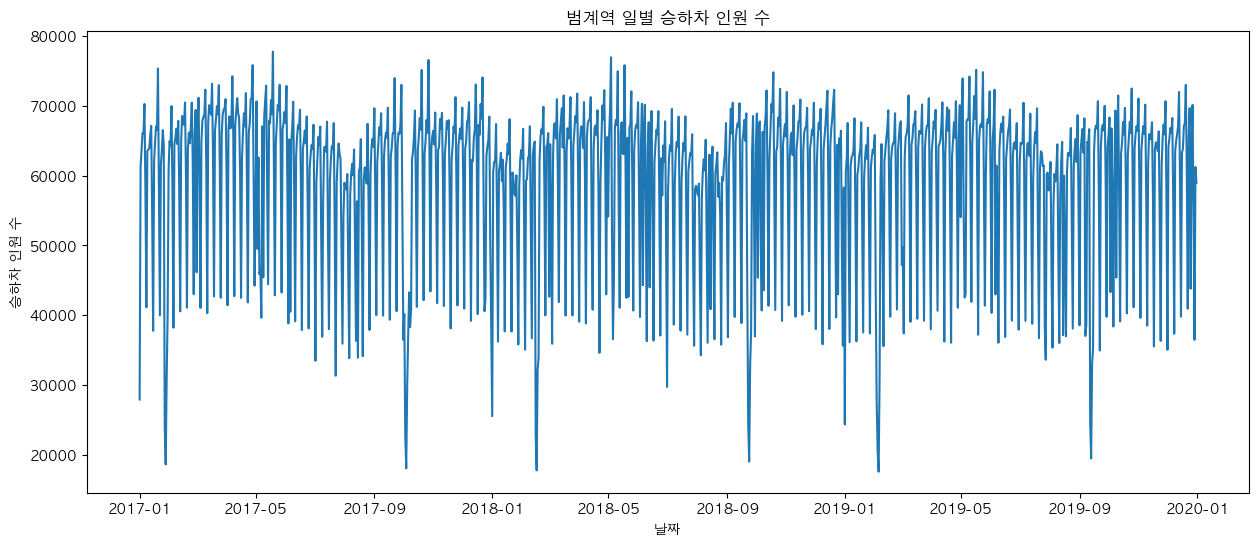

In [4]:
plt.figure(figsize=(15,6))
plt.plot(ts)
plt.title("범계역 일별 승하차 인원 수")
plt.xlabel("날짜")
plt.ylabel("승하차 인원 수")
plt.show()

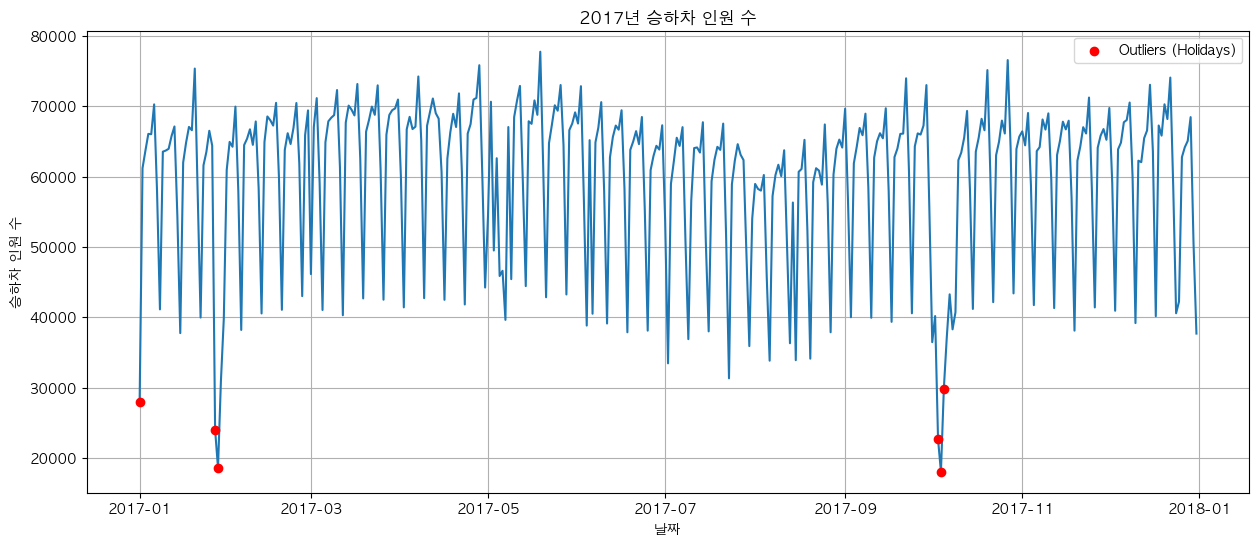

In [6]:
#특정 1년치만 확인
target_year = '2017' 

# Pandas의 날짜 인덱싱을 사용하여 해당 연도만 추출
ts_subset = ts[target_year]

# 그래프 그리기
plt.figure(figsize=(15, 6))
plt.plot(ts_subset)
plt.title(f'{target_year}년 승하차 인원 수')
plt.xlabel('날짜')
plt.ylabel('승하차 인원 수')
plt.grid(True)

# 명절 등 특이점(Outlier) 확인을 돕기 위해 낮은 값에 표시를 해볼 수도 있습니다 (옵션)
# 승객 수가 3만 명 이하인 날짜에 빨간 점 표시
outliers = ts_subset[ts_subset < 30000]
plt.scatter(outliers.index, outliers.values, color='red', label='Outliers (Holidays)', zorder=5)

plt.legend()
plt.show()

1. 규칙적인 파동 관찰
    - 그래프를 보면 규칙적으로 위아래로 움직이는 것이 보인다.
2. 빨간 점(이상치)
    - 새해, 설날, 추석 등 명절 때 승객가 급격히 줄어든다.

## 2. 정상성 검정(ADF)

- 통계적 수치로 정상을 학인하기 위해 검정 진행
- ADF(Augmented Dickey-Fuller) Test 사용

In [9]:
def check_stationarity(timeseries):
    print("정상성 검정 - ADF")

    adf_result = adfuller(timeseries)
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'ADF p-value: {adf_result[1]:.4f}')

    print("정상성 검정 - KPSS")
    # 2. KPSS Test (귀무가설: 정상 / 대립가설: 비정상)
    kpss_result = kpss(timeseries, regression='c', nlags='auto')
    print(f'KPSS Statistic: {kpss_result[0]:.4f}')
    print(f'KPSS p-value: {kpss_result[1]:.4f}')

check_stationarity(ts)

정상성 검정 - ADF
ADF Statistic: -5.8476
ADF p-value: 0.0000
정상성 검정 - KPSS
KPSS Statistic: 0.0954
KPSS p-value: 0.1000


**ADF p-value < 0.05 -> 정상성**

**KPSS p-value > 0.5 -> 정상성**

ADF 검정은 정상성을 가진 시계열 데이터로 판단했다.
또한 KPSS 검정의 결과 또한 정상성을 가진 시계열 데이터로 판단했지만, 
시각적으로 관찰할 때의 계절성을 확인했기 때문에 모델의 예측력을 높이기 위해 계절 차분을 적용하기로 결정했다.

따라서 로그 변환과 계절 차분을 수행한다.


## 3. 변환 및 차분

- 비정상 데이터(계절성 포함)를 정상 데이터로 만들기 위해 로그 변환과 계절 차분을 수행한다.

정상성 검정 - ADF
ADF Statistic: -10.3484
ADF p-value: 0.0000
정상성 검정 - KPSS
KPSS Statistic: 0.0071
KPSS p-value: 0.1000


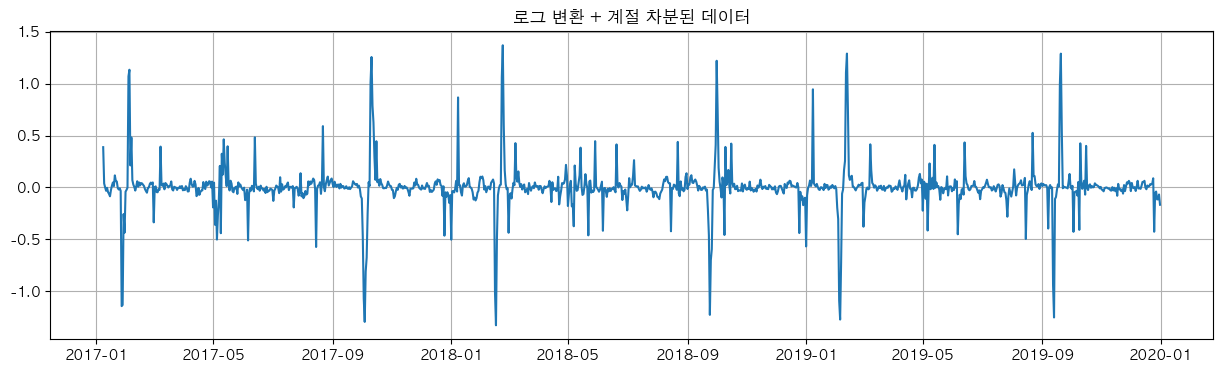

In [11]:
# 로그 변환
ts_log = np.log1p(ts)

# 계절 차분 (7일 주기)
ts_diff = ts_log.diff(7).dropna()

check_stationarity(ts_diff)

plt.figure(figsize=(15, 4))
plt.plot(ts_diff)
plt.title('로그 변환 + 계절 차분된 데이터')
plt.grid(True)
plt.show()

## 4. 모형 식별(ACF, PACF)
- 정상화된 데이터(`ts_diff`)의 자기상관 그래프를 보고 $(p, q)$와 $(P, Q)$를 결정한다.

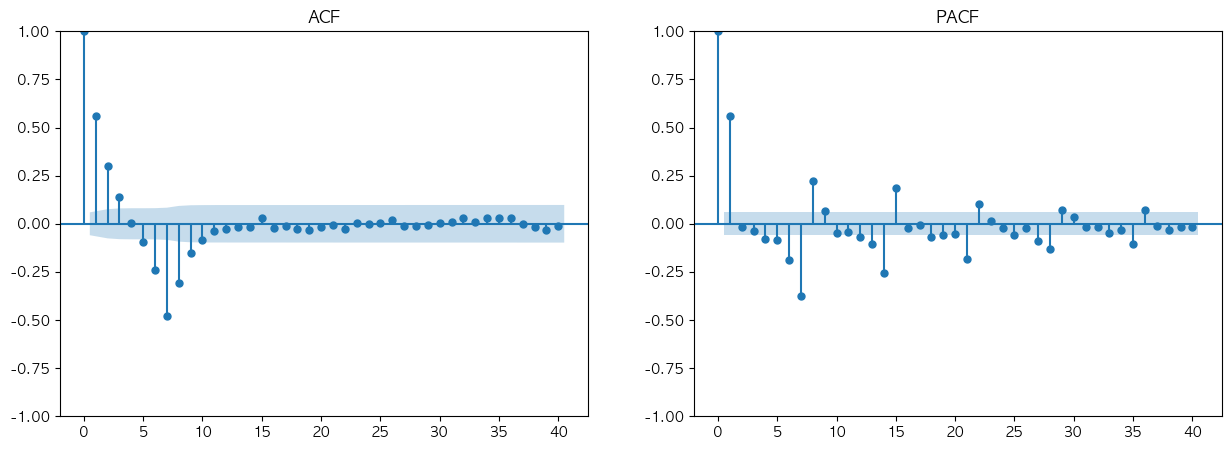

In [14]:
#ACF, PACF 그래프 그리기
fig, ax = plt.subplots(1, 2, figsize=(15,5))
plot_acf(ts_diff, ax=ax[0], lags=40, title= "ACF")
plot_pacf(ts_diff, ax=ax[1], lags=40, title= "PACF")
plt.show()

## 5. 모형 적합 
- 식별된 차수를 바탕으로 모델을 학습시킨다.

In [ ]:
# SARIMA 모델 적합
# 주의: d=0인 이유는 위에서 이미 diff(7)을 수행해서 정상성을 확보했기 때문이라고 가정하거나,
# 원본 데이터(ts_log)에 넣을 거면 order=(p, 0, q), seasonal_order=(P, 1, Q, 7)로 설정합니다.

# 여기서는 statsmodels가 알아서 차분하게 원본(로그) 데이터를 넣고 D=1을 명시합니다.
order = (1, 0, 0)             # (p, d, q) -> d=0 (원데이터가 ADF 통과했으므로)
seasonal_order = (0, 1, 1, 7) # (P, D, Q, s) -> D=1 (계절 차분)

model = SARIMAX(ts_log,  #로그 변환만 진행된 데이터(계절 차분 X)
                order=order, 
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit()
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                     Total_Ridership   No. Observations:                 1095
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood                 653.906
Date:                             Sat, 06 Dec 2025   AIC                          -1301.813
Time:                                     19:49:26   BIC                          -1286.858
Sample:                                 01-01-2017   HQIC                         -1296.150
                                      - 12-31-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5707      0.010     59.206      0.000       0.552       0.590
ma.S.L7       -1.0000      

## 6. 모형 진단
- 만들어진 모델의 잔차가 **백색 잡은**인지 확인합니다.

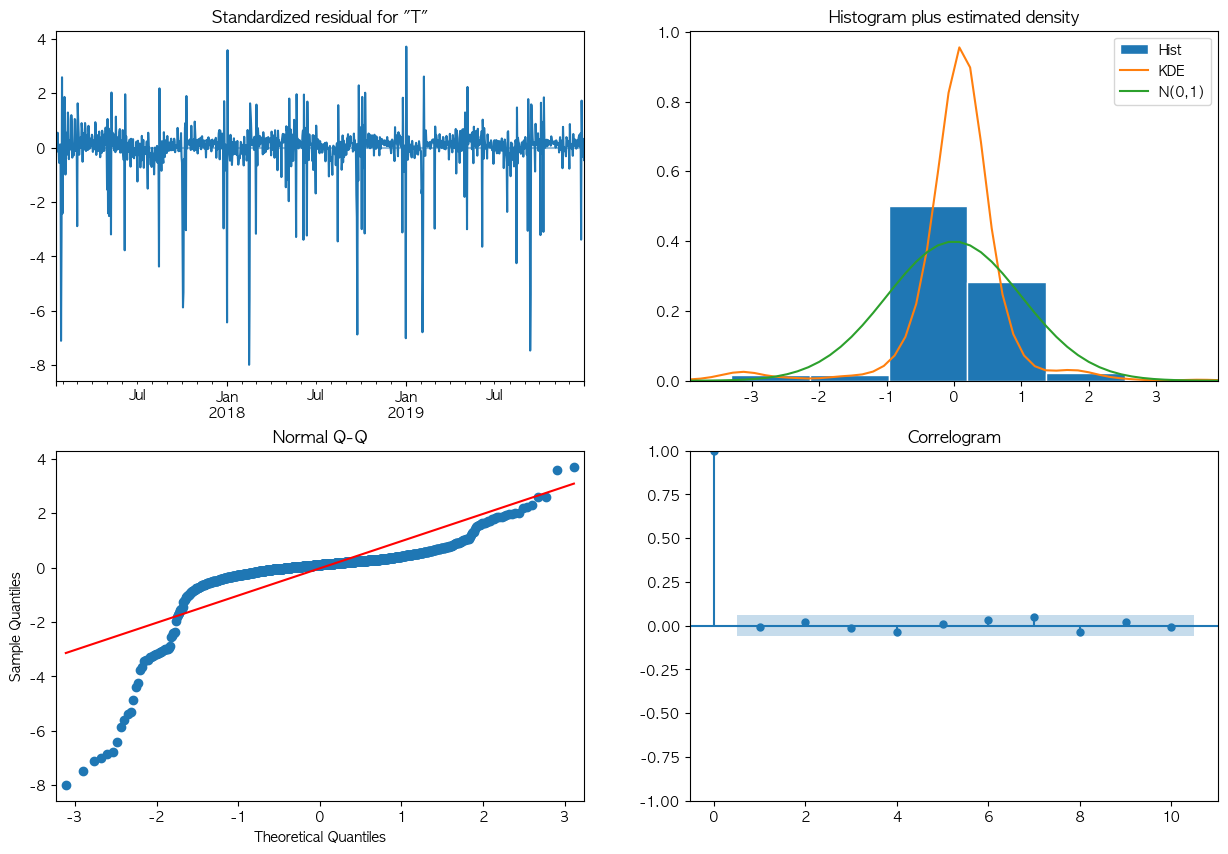


[Residual Normality & Autocorrelation Test]
        lb_stat      lb_pvalue
10  1176.765821  1.478887e-246
20  1177.093454  5.920392e-237
Jarque-Bera p-value: 0.0000


In [16]:
# 잔차 가져오기
residuals = results.resid

# 1. 잔차 시각화 (4-pack plot)
results.plot_diagnostics(figsize=(15, 10))
plt.show()

# 2. 통계적 검정 (Ljung-Box, Jarque-Bera)
print("\n[Residual Normality & Autocorrelation Test]")

# Ljung-Box (자기상관): p-value > 0.05 여야 좋음 (귀무가설: 자기상관 없음)
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

# Jarque-Bera (정규성): p-value > 0.05 여야 좋음 (귀무가설: 정규분포임)
jb_stat, jb_pval = jarque_bera(residuals)
print(f'Jarque-Bera p-value: {jb_pval:.4f}')

## 최적의 조합 찾아보기

In [18]:
!pip install tqdm

  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-4.67.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 9.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Grid Search 시작... (시간이 조금 걸립니다)

✅ 최적 모델 찾기 완료!
Best AIC: -1309.64
Best Order (p,d,q): (1, 0, 0)
Best Seasonal Order (P,D,Q,s): (1, 0, 1, 7)
                                      SARIMAX Results                                      
Dep. Variable:                     Total_Ridership   No. Observations:                 1095
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood                 658.818
Date:                             Sat, 06 Dec 2025   AIC                          -1309.637
Time:                                     19:55:29   BIC                          -1289.672
Sample:                                 01-01-2017   HQIC                         -1302.080
                                      - 12-31-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

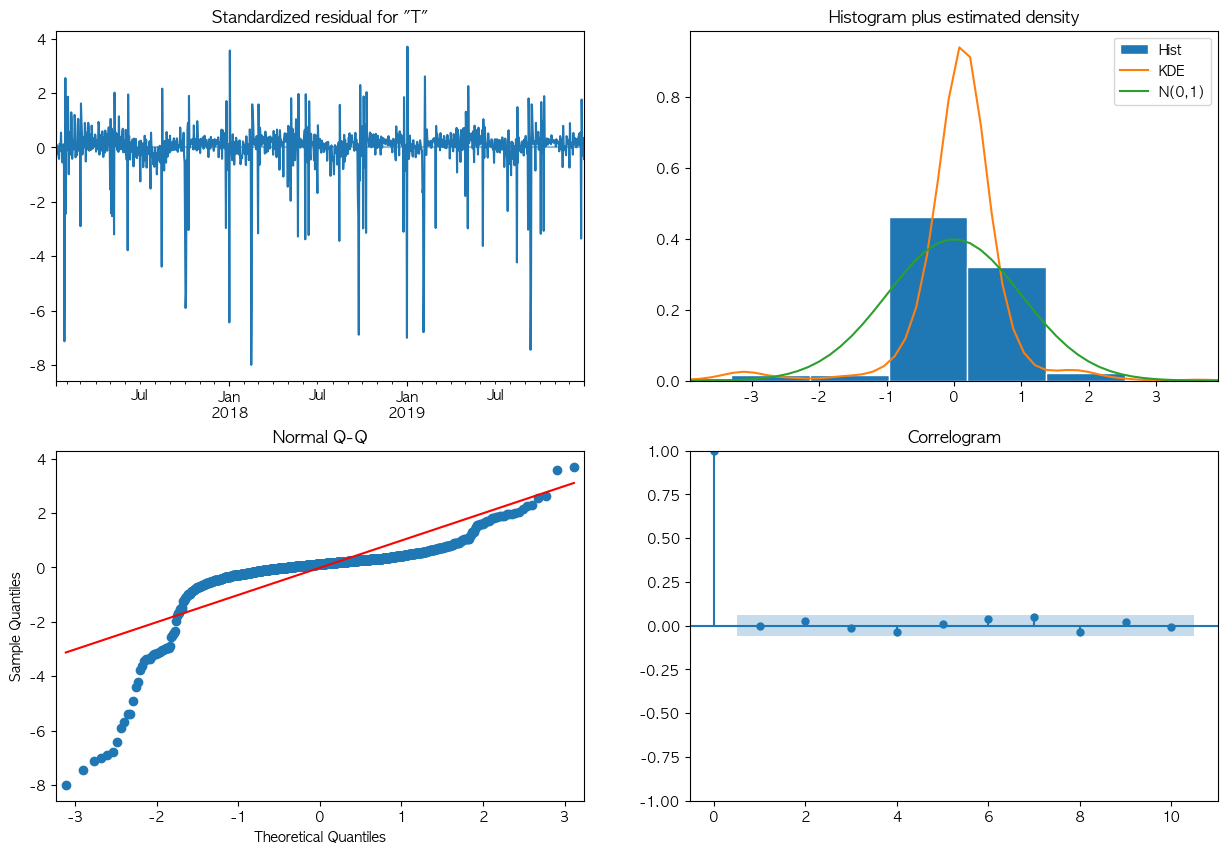


[Residual Normality & Autocorrelation Test]
       lb_stat      lb_pvalue
10  651.878570  1.330604e-133
20  652.514023  2.414159e-125
Jarque-Bera p-value: 0.0000


In [20]:
import itertools
import tqdm

# 1. 탐색할 파라미터 범위 설정
# p, q는 0~2, P, Q는 0~1 정도로 설정 (너무 크면 과적합 위험)
p = d = q = range(0, 2)
P = D = Q = range(0, 2)
s = 7 # 계절 주기

# 모든 가능한 조합 생성
pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q))
# seasonal_pdq에 주기 s 추가 -> [(0,0,0,7), (0,0,1,7)...]
seasonal_pdq_s = [(x[0], x[1], x[2], s) for x in seasonal_pdq]

best_aic = float("inf")
best_param = None
best_seasonal_param = None

print("Grid Search 시작... (시간이 조금 걸립니다)")

# 2. Grid Search 수행
for param in pdq:
    for param_seasonal in seasonal_pdq_s:
        try:
            # SARIMA 모델 시도
            mod = SARIMAX(ts_log,
                          order=param,
                          seasonal_order=param_seasonal,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            results = mod.fit(disp=False)
            
            # AIC가 더 낮으면 갱신 (낮을수록 좋음)
            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal_param = param_seasonal
                # 진행 상황 출력 (옵션)
                # print(f'ARIMA{param}x{param_seasonal} - AIC:{results.aic:.2f}')
                
        except:
            continue

print("\n" + "="*50)
print(f"✅ 최적 모델 찾기 완료!")
print(f"Best AIC: {best_aic:.2f}")
print(f"Best Order (p,d,q): {best_param}")
print(f"Best Seasonal Order (P,D,Q,s): {best_seasonal_param}")
print("="*50)

# 3. 최적 모델로 다시 학습 및 진단
best_model = SARIMAX(ts_log, 
                     order=best_param, 
                     seasonal_order=best_seasonal_param,
                     enforce_stationarity=False,
                     enforce_invertibility=False)
best_results = best_model.fit()

print(best_results.summary())

# 잔차 진단 다시 수행
best_residuals = best_results.resid
best_results.plot_diagnostics(figsize=(15, 10))
plt.show()

# 2. 통계적 검정 (Ljung-Box, Jarque-Bera)
print("\n[Residual Normality & Autocorrelation Test]")

# Ljung-Box (자기상관): p-value > 0.05 여야 좋음 (귀무가설: 자기상관 없음)
lb_test = acorr_ljungbox(best_residuals, lags=[10, 20], return_df=True)
print(lb_test)

# Jarque-Bera (정규성): p-value > 0.05 여야 좋음 (귀무가설: 정규분포임)
jb_stat, jb_pval = jarque_bera(best_residuals)
print(f'Jarque-Bera p-value: {jb_pval:.4f}')


지하철 데이터 특성상 명절 이상치 때문에 ARIMA만으로는 완벽한 백색 잡음을 만들기 어렵습니다.

Grid Search를 통해 AIC를 최소화하는 최적 모형을 선정하였으나, 명절 연휴의 극단적인 승객 감소로 인해 잔차의 자기상관이 완전히 제거되지는 않았다. 이는 단순 시계열 모형의 한계이며, 추후 휴일 효과를 반영한 회귀 결합 모형(Regression with ARIMA errors)으로 발전시킬 필요가 있다.